<h1 style="text-align: center;">Telkomsel Exploratory Data Analysis</h1>
<h3 style="text-align: center;">Muhammad Rafi Andrianto</h3>
<h3 style="text-align: center;">Yoanita Dwi Harlandi</h3>

---

## **Section 1. Business Context**

**1.1 Context**

Sebagai operator telekomunikasi terbesar di Indonesia yang mengelola infrastruktur broadband berskala masif, Telkomsel menghadapi perubahan lanskap industri yang dinamis. Pergeseran perilaku konsumen dari layanan legacy (Voice/SMS) menuju layanan Data/Internet memaksa perusahaan terus berinovasi menelurkan berbagai produk kuota data guna mengakuisisi pengguna prabayar baru secara masif melalui aplikasi MyTelkomsel maupun jaringan konter tradisional (Digipos).

Namun, persaingan harga yang sangat agresif (price war) di pasar seluler Indonesia melahirkan tantangan internal yang serius:

1. Fenomena **"Bakar Perdana"**: Paket kuota promo pada kartu perdana baru sengaja di-subsidi agar harganya jauh lebih murah per Gigabyte dibandingkan biaya perpanjangan (top-up) paket normal. Alih-alih melakukan loyalitas pengisian ulang, banyak konsumen memilih membuang kartu SIM lama mereka setelah kuotanya habis dan membeli kartu perdana baru. Hal ini menciptakan metrik semu di mana pertumbuhan pelanggan baru terlihat sangat tinggi (Gross Additions), namun diiringi oleh tingkat kerontokan pelanggan yang luar biasa besar (Churn Rate). Akibatnya, nilai rata-rata pendapatan per pengguna atau ARPU (Average Revenue Per User) perusahaan mengalami penurunan tajam.

2. **Abuse Program Device Bundling**: Kebocoran anggaran subsidi juga terdeteksi pada program kerjasama perangkat premium (misal: beli smartphone gratis kuota 1 tahun). Terdapat indikasi sindikat fraud yang membeli perangkat bundling tersebut untuk diambil kartu SIM subsidi kuotanya demi dijual eceran (dimanfaatkan pada perangkat modem atau HP lain), sedangkan unit smartphone-nya dijual terpisah. Hal ini membuat anggaran subsidi bernilai miliaran rupiah melayang tanpa menghasilkan pelanggan bernilai tinggi (high-value subscribers) yang diharapkan.

Melalui pendekatan berbasis data, tim Data Analytics dituntut untuk melakukan analisis forensik terhadap log aktivitas penggunaan data (Call Data Record - CDR), pelacakan nomor identitas perangkat (IMEI), dan status kepatuhan registrasi prabayar. Langkah ini mendesak dilakukan agar Telkomsel dapat mengubah strategi bisnis dari yang semula berfokus pada kuantitas (mengejar jumlah pengguna baru) menjadi berfokus pada kualitas (retensi pelanggan setia yang profitabel).

**1.2 Problem Statements**

Masalah utama yang dihadapi perusahaan adalah merosotnya nilai ARPU (Average Revenue Per User) serta terjadinya kebocoran anggaran subsidi akibat praktik fraud "Bakar Perdana" dan manipulasi program Device Bundling (IMEI Mismatch).

Secara operasional dan teknis data, masalah tersebut dirumuskan ke dalam beberapa pertanyaan turunan berikut:
1. **Deteksi Potensi Kebocoran Anggaran:**: Mengidentifikasi potensi penyalahgunaan paket bundling premium di mana identitas perangkat yang digunakan tidak sesuai dengan perangkat yang didaftarkan (registered_imei $\neq$ used_imei)?

2. **Standarisasi Infrastruktur Data**: Seberapa besar tingkat inkonsistensi penulisan tipe jaringan (network_type) pada log BTS yang masuk ke database pusat, yang berpotensi memicu bias pada visualisasi performa jaringan broadband?

3. **Risiko Kepatuhan Regulasi (Compliance Risk)**: Berapa persentase nomor pelanggan yang tidak memiliki kejelasan status registrasi NIK/KK, yang menempatkan perusahaan pada risiko denda audit dari Kominfo?

4. **Anomali Sistem & Sinkronisasi**: Berapa banyak sesi penggunaan internet yang bocor secara ilegal sebelum kartu SIM resmi diaktivasi (session_time < activation_date) akibat ketidaksinkronan sistem HLR dan Billing?
    - Berapa banyak temuan outlier pemakaian data ekstrem (nilai fiktif bug billing) yang dapat merusak analisis rata-rata konsumsi data riil pelanggan?


**1.3 Key Objective**

Tujuan utama dari projek analisis ini adalah memberikan rekomendasi strategis berbasis data untuk menghentikan kebocoran pendapatan perusahaan, dengan sasaran spesifik sebagai berikut:

- Investigasi Pola Bakar Perdana & Fraud: Menganalisis pola penggunaan data pada setiap jenis paket dan mengidentifikasi indikasi penyalahgunaan program Device Bundling.

- Perlindungan Subsidi (Subsidy Protection): Menyediakan basis data untuk penerapan sistem IMEI Locking, sehingga kuota subsidi otomatis hangus jika kartu SIM dipindahkan ke perangkat non-mitra.

- Kepatuhan Sistem (Regulatory Compliance): Mengisolasi nomor-nomor dengan status NIK/KK kosong agar segera dilakukan pemblokiran massal guna mematuhi regulasi Kominfo dan menghindari denda eksternal.

- Integritas Data & Perbaikan Sistem: Menyediakan laporan bug (System Bug Report) bagi tim Data Engineering dan Network Operations untuk menutup celah kebocoran kuota pada database HLR serta membersihkan anomali pencatatan sistem billing.

## **Section 2. Data Understanding**

**2.1 General Information**

In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sub_raw = pd.read_csv('../data/raw/tsel_subscribers.csv')
pkg_raw = pd.read_csv('../data/raw/tsel_packages.csv')
usage_raw = pd.read_csv('../data/raw/tsel_data_usage.csv')

print(f"Subscribers Shape : {sub_raw.shape}")
print(f"Packages Shape    : {pkg_raw.shape}")
print(f"Data Usage Shape  : {usage_raw.shape}")

Subscribers Shape : (35000, 4)
Packages Shape    : (10, 3)
Data Usage Shape  : (300000, 7)


- tsel_subscribers.csv: Terdiri dari 35.000 baris dan 4 kolom (Master data profil pelanggan)
- tsel_packages.csv: Terdiri dari 10 baris dan 3 kolom (Katalog produk paket data)
- tsel_data_usage.csv: Terdiri dari 300.000 baris dan 7 kolom (Log aktivitas Call Data Record / CDR)

**2.2 Feature Information**
 
**2.2.1 tsel_subscribers.csv**

| Nama Kolom | Deskripsi |
| :--- | :--- |
| **msisdn** | Nomor HP pelanggan (MSISDN). |
| **activation_date** | Tanggal kartu SIM diaktifkan/registrasi. |
| **nik_kk_status** | Status registrasi NIK/KK. |
| **registered_imei** | IMEI smartphone yang didaftarkan saat beli paket bundling (Bisa NaN jika bukan paket bundling). |


**2.2.2 tsel_packages.csv**


| Nama Kolom | Deskripsi |
| :--- | :--- |
| **package_code** | Kode unik paket. |
| **package_name** | Nama paket komersial (Promo Perdana, Halo Bundling, OMG!, Kuota Ketengan). |
| **price** | Harga paket. |

**2.2.3 tsel_data_usage.csv**

| Nama Kolom | Deskripsi |
| :--- | :--- |
| **session_id** | ID unik sesi internet. |
| **msisdn** | Nomor HP pengguna. |
| **package_code** | Kode paket yang memotong kuota. |
| **used_imei** | IMEI HP yang dipakai saat internetan. |
| **session_time** | Tanggal & Jam pengguna menyalakan koneksi data. |
| **network_type** | Jaringan yang dipakai. |
| **payload_mb** | Jumlah Megabyte (MB) yang disedot dalam sesi tersebut. |



In [3]:
print(f"--- subscribers data type ---\n{sub_raw.dtypes}\n")
print(f"--- package data type ---\n{pkg_raw.dtypes}\n")
print(f"--- usage data type ---\n{usage_raw.dtypes}")

--- subscribers data type ---
msisdn               int64
activation_date     object
nik_kk_status       object
registered_imei    float64
dtype: object

--- package data type ---
package_code    object
package_name    object
price            int64
dtype: object

--- usage data type ---
session_id       object
msisdn            int64
package_code     object
used_imei         int64
session_time     object
network_type     object
payload_mb      float64
dtype: object


**2.3 Statistics Summary**

In [4]:
usage_raw['payload_mb'].describe()

count    300000.000000
mean       6159.144994
std       71485.176443
min        -150.500000
25%         506.337500
50%        1024.020000
75%        1541.155000
max      999999.900000
Name: payload_mb, dtype: float64

Evaluasi metrik statistik deskriptif pada kolom inti payload_mb menunjukkan anomali matematika:

- Penyimpangan Rata2 (Skewness Ekstrem): Nilai rata2 (mean) penggunaan internet berada di angka 6.159,14 MB, sangat jauh melompati nilai tengahnya (median/50%) yang hanya berada di angka 1.024,02 MB. Hal ini membuktikan adanya tarikan dari nilai outliers yang sangat extreme.

- Indikasi Error Sistem: Nilai minimum berada pada angka -150.50 MB, sebuah nilai negatif yang tidak masuk akal untuk kuota pemakaian data fisik

- Nilai maksimum berada pada angka 999.999,90 MB (~1 Terabyte), nilai yang di luar normal

## **Section 3. Data Cleaning**

Tahap ini untuk mengidentifikasi cacat log data seperti anomali, nilai kosong, inkonsistensi format, dan variabel duplikat. Langkah ini menjamin bahwa pengolahan data pada tahap berikutnya menghasilkan visualisasi dan metrik2 yang akurat tanpa bias akibat kerusakan data/sistem

### **3.1 Missing Values**

In [5]:
print("--- tsel_subscribers ---")
print(sub_raw.isna().sum())

print("\n--- tsel_data_usage ---")
print(usage_raw.isna().sum())

invalid_nik = sub_raw[sub_raw['nik_kk_status'].isna()]
pct_invalid_nik = (len(invalid_nik) / len(sub_raw)) * 100

print(f"\nPersentase NIK/KK Status bermasalah/missing: {pct_invalid_nik:.2f}%")

--- tsel_subscribers ---
msisdn                 0
activation_date        0
nik_kk_status       5202
registered_imei    24470
dtype: int64

--- tsel_data_usage ---
session_id      0
msisdn          0
package_code    0
used_imei       0
session_time    0
network_type    0
payload_mb      0
dtype: int64

Persentase NIK/KK Status bermasalah/missing: 14.86%


- **nik_kk_status (5202)**: Dari perspektif hukum dan kepatuhan (regulatory compliance), ketiadaan status registrasi sebesar 14,86% merupakan sinyal bahaya risiko denda audit dari Kominfo. Baris ini tidak boleh dihapus dari basis data historis karena nomor-nomor ini harus diisolasi untuk dilaporkan ke tim Fraud & Security guna dilakukan pemblokiran massal.

- **registered_imei (24470)**: Berdasarkan analisis konteks bisnis, ketiadaan data IMEI terdaftar ini bersifat normal dan valid. Pelanggan prabayar reguler yang membeli kartu perdana biasa (non-bundling smartphone) memang tidak meregistrasikan IMEI perangkat mereka saat aktivasi. Mereka membeli kartu SIM secara terpisah untuk dimasukkan ke HP apa saja yang sudah mereka miliki 

### **3.2 Duplicated Values**

In [6]:
print(f"Duplikat di tsel_subscribers : {sub_raw.duplicated().sum()}")
print(f"Duplikat di tsel_packages    : {pkg_raw.duplicated().sum()}")
print(f"Duplikat di tsel_data_usage  : {usage_raw.duplicated().sum()}")

Duplikat di tsel_subscribers : 0
Duplikat di tsel_packages    : 0
Duplikat di tsel_data_usage  : 0


Hasil pengujian mengonfirmasi tidak ada record yang terduplikasi di seluruh baris tabel. Hal ini membuktikan bahwa struktur keunikan data Primary Key (msisdn, package_code, session_id) berada dalam kondisi aman dan terbebas dari redundansi sistem pencatatan log.

### **3.3 Identify Spelling Errors**

In [7]:
usage_raw['network_type'].value_counts()

network_type
4G        89981
LTE       44884
4G LTE    30339
5G        30075
4g        29833
WCDMA     15225
3G        15076
NR        14941
HSDPA     14905
5g        14741
Name: count, dtype: int64

bisa dilihat adanya inkonsistensi penulisan teks yang terjadi akibat variasi format pengiriman log teknis dari mesin vendor tower BTS yang berbeda2 ke database pusat. Jika inkonsistensi ini tidak ditangani, hasil agregasi performa jaringan broadband akan pecah menjadi 10 bagian terpisah (misalnya performa 4G seolah berbeda dengan LTE atau 4g), sehingga visualisasi data menjadi bias dan dapat menyesatkan stakeholders

### **3.4 Identify Anomaly Values**

In [8]:
sub_dt = sub_raw[['msisdn', 'activation_date']].copy()
sub_dt['activation_date'] = pd.to_datetime(sub_dt['activation_date'])

usage_dt = usage_raw[['msisdn', 'session_time', 'payload_mb', 'session_id', 'package_code']].copy()
usage_dt['session_time'] = pd.to_datetime(usage_dt['session_time'])

#merge untuk validasi tanggal aktivasi dengan tanggal session penggunaan
df_merge_time = pd.merge(usage_dt, sub_dt, on='msisdn', how='left')
df_merge_time = pd.merge(df_merge_time, pkg_raw, on='package_code', how='inner')
anomaly_time = df_merge_time[df_merge_time['session_time'] < df_merge_time['activation_date']]

print(f"jumlah sesi internet SEBELUM tanggal aktivasi: {len(anomaly_time)}")
anomaly_time.head()

jumlah sesi internet SEBELUM tanggal aktivasi: 12008


,msisdn,session_time,payload_mb,session_id,package_code,activation_date,package_name,price
26,82254454198,2023-04-18,133.47,CDR000000027,PKG-008,2023-04-20,Combo Sakti 25GB,100000
34,82222192600,2023-10-04,758.03,CDR000000035,PKG-004,2023-10-11,Halo Bundling Samsung,200000
63,85272766900,2023-04-07,1090.95,CDR000000064,PKG-003,2023-04-09,Halo Bundling iPhone,250000
104,82120468327,2023-10-17,760.71,CDR000000105,PKG-010,2023-10-18,Kuota Ketengan TikTok,6000
124,81188580169,2023-02-15,409.70,CDR000000125,PKG-004,2023-02-18,Halo Bundling Samsung,200000


Secara logika bisnis prabayar, aktivitas internetan sebelum registrasi kartu SIM adalah kegagalan sistem yang mustahil (kebocoran kuota gratis). Hal ini mengonfirmasi adanya bug sinkronisasi antara database dengan sistem penagihan.

In [9]:
outlier_extreme = usage_raw[usage_raw['payload_mb'] >= 999999.9]
outlier_extreme_min = usage_raw[usage_raw['payload_mb'] < 0] 
print(f"\njumlah sesi yang melebihi 900,000 MB: {len(outlier_extreme)}")
print(f"jumlah sesi yang dibawah dari 0 MB (negatif): {len(outlier_extreme_min)}\n")

print("top nilai terbesar payload_mb:")
print(usage_raw['payload_mb'].nlargest())

print("\ntop nilai negatif payload_mb:")
print(usage_raw['payload_mb'].nsmallest())


jumlah sesi yang melebihi 900,000 MB: 1544
jumlah sesi yang dibawah dari 0 MB (negatif): 1469

top nilai terbesar payload_mb:
2       999999.9
451     999999.9
1118    999999.9
1353    999999.9
1529    999999.9
Name: payload_mb, dtype: float64

top nilai negatif payload_mb:
52    -150.5
144   -150.5
270   -150.5
280   -150.5
300   -150.5
Name: payload_mb, dtype: float64


nilai 999.999,9 MB (~1 Terabyte dalam satu sesi) muncul sebanyak 1.544 kali dan nilai -150,5 MB muncul sebanyak 1469 kali. Jika dipertahankan, nilai korup ini mendistorsi nilai rata2 (mean) penggunaan data seperti yang dari seharusnya ~1 GB melonjak ke 6,1 GB, sehingga merusak pemodelan kapasitas jaringan.

### **3.5 Creating Clean Datasets**

In [10]:
sub_clean = sub_raw.copy()
pkg_clean = pkg_raw.copy()
usage_clean = usage_raw.copy()

sub_clean['activation_date'] = pd.to_datetime(sub_clean['activation_date'])
sub_clean['registered_imei'] = sub_clean['registered_imei'].astype('Int64')
usage_clean['session_time'] = pd.to_datetime(usage_clean['session_time'])

In [11]:
sub_clean.dtypes

msisdn                      int64
activation_date    datetime64[ns]
nik_kk_status              object
registered_imei             Int64
dtype: object

In [12]:
# Tangani Missing Value pada NIK/KK Status (Ubah NaN jadi missing/unregis)
sub_clean['nik_kk_status'] = sub_clean['nik_kk_status'].fillna('Missing/Unregistered')

In [13]:
# Standardisasi Network Type (mapping 10 variasi menjadi 3)
network_map = {
    '4G': '4G', 
    'LTE': '4G', 
    '4G LTE': '4G', 
    '4g': '4G',
    '5G': '5G', 
    'NR': '5G', 
    '5g': '5G',
    'WCDMA': '3G', 
    '3G': '3G', 
    'HSDPA': '3G'
}
usage_clean['network_type'] = usage_clean['network_type'].map(network_map)
usage_clean['network_type'].value_counts()

network_type
4G    195037
5G     59757
3G     45206
Name: count, dtype: int64

In [14]:
# Hapus outlier dan value aneh pada Payload MB (hapus nilai < 0 dan nilai extreme 999999.9)
usage_clean = usage_clean[(usage_clean['payload_mb'] >= 0) & (usage_clean['payload_mb'] < 999999.9)]

# Hapus sesi internet yang dipakai sebelum tanggal aktivasi kartu
# merge sementara dengan data activation_date untuk memfilter baris yang valid
df_merge_filter = pd.merge(usage_clean, sub_clean[['msisdn', 'activation_date']], on='msisdn', how='left')
usage_clean = df_merge_filter[df_merge_filter['session_time'] >= df_merge_filter['activation_date']].drop(columns=['activation_date'])

In [15]:
usage_clean['payload_mb'].describe()

count    285123.000000
mean       1023.542969
std         590.941434
min           0.010000
25%         511.490000
50%        1023.800000
75%        1535.645000
max        2047.980000
Name: payload_mb, dtype: float64

In [16]:
# save to csv
sub_clean.to_csv('../data/cleaned/clean_subscribers.csv', index=False)
usage_clean.to_csv('../data/cleaned/clean_data_usage.csv', index=False)
pkg_raw.to_csv('../data/cleaned/clean_package.csv', index=False)

## **Section 4. Analytics**

In [17]:
df_sub = pd.read_csv('../data/cleaned/clean_subscribers.csv')
df_usage = pd.read_csv('../data/cleaned/clean_data_usage.csv')
df_pkg = pd.read_csv('../data/cleaned/clean_package.csv')

In [18]:
print(f"Subscribers Shape Before : {sub_raw.shape}")
print(f"Packages Shape Before    : {pkg_raw.shape}")
print(f"Data Usage Shape Before  : {usage_raw.shape}")
print("-"*40)
print(f"Subscribers Shape After  : {df_sub.shape}")
print(f"Packages Shape After     : {df_pkg.shape}")
print(f"Data Usage Shape After   : {df_usage.shape}")


Subscribers Shape Before : (35000, 4)
Packages Shape Before    : (10, 3)
Data Usage Shape Before  : (300000, 7)
----------------------------------------
Subscribers Shape After  : (35000, 4)
Packages Shape After     : (10, 3)
Data Usage Shape After   : (285123, 7)


### **4.1 Analisis Kasus Fraud IMEI Mismatch (Device Bundling Abuse)**

Program bundling premium (seperti Halo Bundling iPhone/Samsung) memiliki beban subsidi harga yang sangat besar dari Telkomsel dengan harapan pengguna akan terus memakai kartu tersebut di smartphone paketan bundling mereka. Jika used_imei (perangkat riil saat internetan) berbeda dengan registered_imei (perangkat saat didaftarkan), ini menjadi bukti bahwa kartu SIM tersebut dicopot untuk digunakan di device lain.

In [19]:
df_analisis = pd.merge(df_usage, df_sub, on='msisdn', how='inner')
df_analisis = pd.merge(df_analisis, df_pkg, on='package_code', how='inner')
df_analisis.head()

,session_id,msisdn,package_code,used_imei,session_time,network_type,payload_mb,activation_date,nik_kk_status,registered_imei,package_name,price
0,CDR000000001,85254880966,PKG-008,350000000003139,2023-02-12 03:33:00,4G,1153.63,2023-02-09,Valid,NaN,Combo Sakti 25GB,100000
1,CDR000000002,85271729455,PKG-009,350000000002881,2023-04-23 21:57:00,4G,224.37,2023-04-02,Valid,NaN,Kuota Ketengan YouTube,5000
2,CDR000000004,81225426120,PKG-006,350000000511814,2023-09-26 14:16:00,4G,1538.98,2023-08-03,Valid,3.500000e+14,Internet OMG! 100GB,160000
3,CDR000000005,85267756806,PKG-010,350000000003958,2023-04-28 02:06:00,4G,1722.07,2023-03-10,Missing/Unregistered,NaN,Kuota Ketengan TikTok,6000
4,CDR000000006,82161437190,PKG-006,350000000215530,2023-03-16 18:46:00,4G,753.83,2023-01-21,Valid,3.500000e+14,Internet OMG! 100GB,160000


In [20]:
# Filter hanya untuk pelanggan program bundling (iphone dan samsung)
# Kolom registered_imei tidak kosong pada pelanggan bundling
df_bundling = df_analisis[df_analisis['registered_imei'].notna()].copy()

# Tandai
df_bundling['imei_status'] = np.where(df_bundling['used_imei'] == df_bundling['registered_imei'], 'Match', 'Mismatch')
df_bundling.head()

,session_id,msisdn,package_code,used_imei,session_time,network_type,payload_mb,activation_date,nik_kk_status,registered_imei,package_name,price,imei_status
2,CDR000000004,81225426120,PKG-006,350000000511814,2023-09-26 14:16:00,4G,1538.98,2023-08-03,Valid,3.500000e+14,Internet OMG! 100GB,160000,Match
4,CDR000000006,82161437190,PKG-006,350000000215530,2023-03-16 18:46:00,4G,753.83,2023-01-21,Valid,3.500000e+14,Internet OMG! 100GB,160000,Match
8,CDR000000010,82171162495,PKG-005,350000009999999,2023-08-28 09:50:00,4G,115.52,2023-07-09,Missing/Unregistered,3.500000e+14,Internet OMG! 50GB,110000,Mismatch
10,CDR000000012,81166998328,PKG-008,350000000236036,2023-09-01 01:43:00,4G,24.99,2023-08-11,Valid,3.500000e+14,Combo Sakti 25GB,100000,Match
23,CDR000000025,81267140856,PKG-005,350000000385242,2023-10-18 06:02:00,5G,509.41,2023-09-12,Valid,3.500000e+14,Internet OMG! 50GB,110000,Match


In [21]:
summary_bundling = df_bundling.groupby('imei_status').agg(
    total_sesi=('session_id', 'count'),
    total_payload_gb=('payload_mb', lambda x: x.sum() / 1024)
).reset_index()

print(summary_bundling)

largest_payload_missmatch = df_bundling[df_bundling['imei_status'] == 'Mismatch'].nlargest(10, 'payload_mb')['payload_mb']
largest_payload_match = df_bundling[df_bundling['imei_status'] == 'Match'].nlargest(10, 'payload_mb')['payload_mb']

print("\nTop 5 Match Payloads (MB):")
print(largest_payload_match.tolist())

print("\nTop 5 Mismatch Payloads (MB):")
print(largest_payload_missmatch.tolist())


  imei_status  total_sesi  total_payload_gb
0       Match       68295      68405.776406
1    Mismatch       17183      17138.703008

Top 5 Match Payloads (MB):
[2047.94, 2047.94, 2047.93, 2047.92, 2047.83, 2047.81, 2047.77, 2047.77, 2047.75, 2047.74]

Top 5 Mismatch Payloads (MB):
[2047.96, 2047.74, 2047.62, 2047.59, 2047.57, 2047.55, 2047.54, 2047.47, 2047.19, 2047.15]



Kita akan melakukan Uji Hipotesis Statistik (Independent T-Test) untuk membuktikan: apakah kelompok yang terindikasi IMEI Mismatch mengkonsumsi kuota (payload_mb) lebih banyak dan extreme dibandingkan kelompok IMEI Match.

Hipotesis Uji:
- $H_0$: Rata-rata konsumsi data per sesi antara pengguna IMEI Match dan IMEI Mismatch adalah Sama.
- $H_1$: Rata-rata konsumsi data per sesi pengguna IMEI Mismatch Signifikan Lebih Tinggi (Bukti eksploitasi kuota subsidi).

In [22]:
# Uji hipotesis statistik (Independent T-Test / Welch's T-Test)
match = df_bundling[df_bundling['imei_status'] == 'Match']['payload_mb']
mismatch = df_bundling[df_bundling['imei_status'] == 'Mismatch']['payload_mb']

t_stat, p_value = stats.ttest_ind(mismatch, match, equal_var=False)

print(f"T-Statistic : {t_stat}")
print(f"P-Value     : {p_value}")

if p_value < 0.05:
    print("Kesimpulan  : Tolak H0! Terdapat perbedaan konsumsi data yang SIGNIFIKAN secara statistik")
    print("              Kelompok IMEI Mismatch terbukti menyedot kuota lebih banyak")
else:
    print("Kesimpulan  : Gagal Tolak H0. Tidak ada perbedaan signifikan")

T-Statistic : -0.8520045539476239
P-Value     : 0.3942192809610171
Kesimpulan  : Gagal Tolak H0. Tidak ada perbedaan signifikan


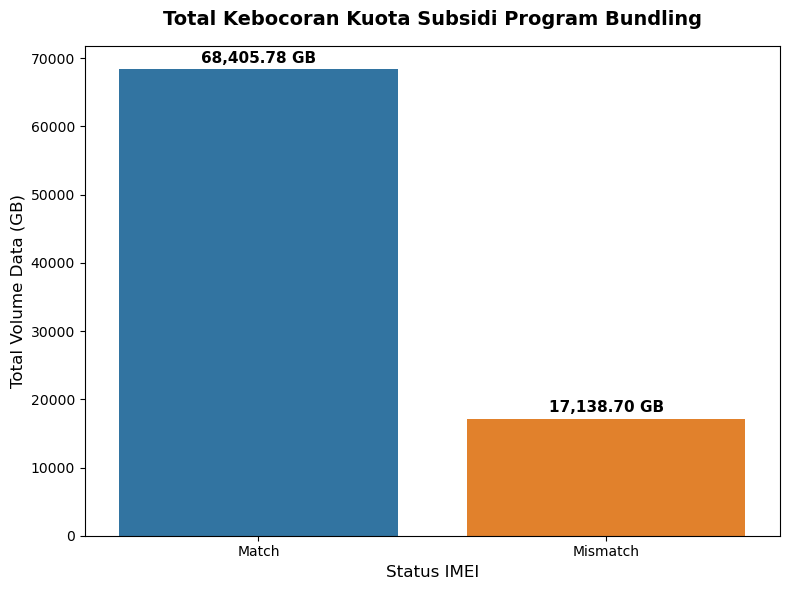

In [23]:
# Visualisasi total kebocoran kuota subsidi
plt.figure(figsize=(8, 6))
sns.barplot(
    data=summary_bundling, 
    x='imei_status', 
    y='total_payload_gb', 
    hue='imei_status'
)

plt.title('Total Kebocoran Kuota Subsidi Program Bundling', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status IMEI', fontsize=12)
plt.ylabel('Total Volume Data (GB)', fontsize=12)

# Menambahkan label angka di atas bar
for p in plt.gca().patches:
    plt.gca().annotate(
        f"{p.get_height():,.2f} GB", 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points', 
        fontsize=11, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

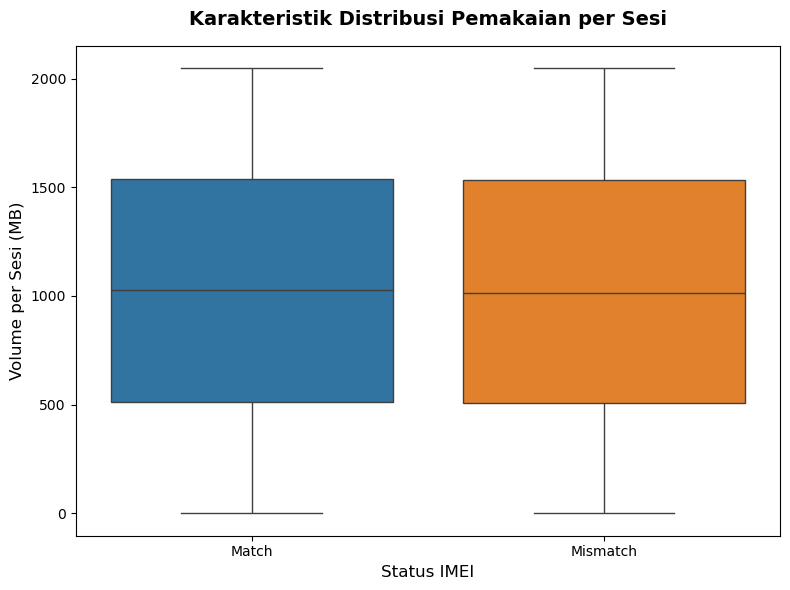

In [24]:
# Visualisasi distribusi pemakaian per sesi
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_bundling, 
    x='imei_status', 
    y='payload_mb', 
    hue='imei_status'
)

plt.title('Karakteristik Distribusi Pemakaian per Sesi', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Status IMEI', fontsize=12)
plt.ylabel('Volume per Sesi (MB)', fontsize=12)

plt.tight_layout()
plt.show()

> ini membuktikan bahwa pelaku fraud device bundling bukan tipe pengguna serakah (tethering abuse massal), melainkan kartu SIM premium tersebut sengaja dicopot dan diecer/dijual kembali ke pengguna prabayar reguler dengan pola pemakaian handphone normal (tetap berkisar di angka ~1 GB per sesi). Anggaran subsidi tetap bocor secara finansial karena target mengakuisisi segmen high-value smartphone users gagal

**Recommend:** Manajemen tidak bisa mendeteksi fraud ini hanya dengan memfilter batasan kuota (karena pemakaiannya normal). Salah satu solusi yang dapat diterapkan adalah implementasi **IMEI Locking** secara real-time pada Core Network (HLR/PCRF). Jika sistem mendeteksi `used_imei` $\neq$ `registered_imei`, paket data bundling premium harus otomatis dinonaktifkan atau diblokir seketika.

### **4.2 Korelasi Fenomena "Bakar Perdana" dengan Risiko Regulasi NIK/KK**

In [25]:
# Crosstab frekuensi nilai absolut
cross_nik_abs = pd.crosstab(df_analisis['package_name'], df_analisis['nik_kk_status'])

# Crosstab persentase
cross_nik_pct = pd.crosstab(df_analisis['package_name'], df_analisis['nik_kk_status'], normalize='index') * 100

print("=== FREKUENSI ABSOLUT ===")
print(cross_nik_abs)

print("\n=== PROPORSI PERSENTASE (%) ===")
print(cross_nik_pct.round(2))

=== FREKUENSI ABSOLUT ===
nik_kk_status           Missing/Unregistered  Valid
package_name                                       
Combo Sakti 15GB                        4259  24300
Combo Sakti 25GB                        4204  24566
Halo Bundling Samsung                   4228  24335
Halo Bundling iPhone                    4180  24173
Internet OMG! 100GB                     4267  24212
Internet OMG! 50GB                      4207  24293
Kuota Ketengan TikTok                   4054  24030
Kuota Ketengan YouTube                  4270  24194
Promo Perdana 15GB                      4224  24644
Promo Perdana 30GB                      4222  24291

=== PROPORSI PERSENTASE (%) ===
nik_kk_status           Missing/Unregistered  Valid
package_name                                       
Combo Sakti 15GB                       14.91  85.09
Combo Sakti 25GB                       14.61  85.39
Halo Bundling Samsung                  14.80  85.20
Halo Bundling iPhone                   14.74  85.26
Inter

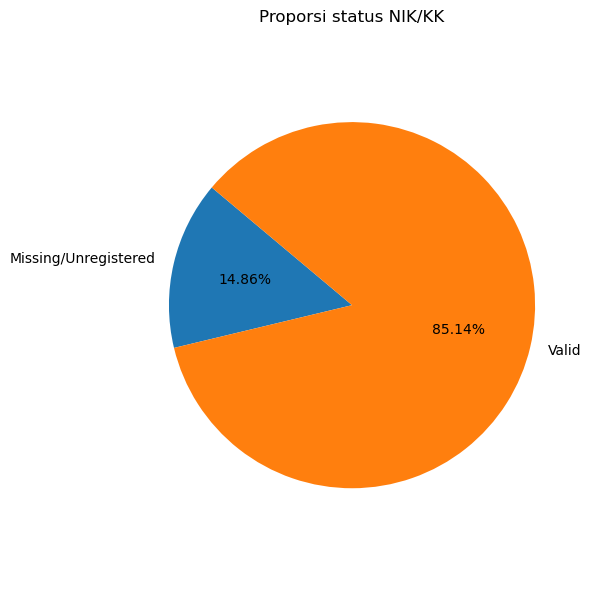

In [26]:
# Hitung jumlah pelanggan per kategori status NIK/KK
registrasi_NIK = df_sub.groupby('nik_kk_status').size()

# Buat pie chart
plt.figure(figsize=(6, 6))
plt.pie(registrasi_NIK, labels=registrasi_NIK.index, autopct='%1.2f%%', startangle=140)
plt.title("Proporsi status NIK/KK")
plt.axis('equal')  # untuk memastikan bentuk lingkaran
plt.tight_layout()
plt.show()

> Jika kita menduga di awal bahwa status NIK/KK bolong (Missing/Unregistered) hanya menumpuk pada paket murah seperti Promo Perdana (gejala konter nakal meregistrasi massal secara ilegal untuk "Bakar Perdana"), data riil ternyata berkata lain.

Proporsi data yang Missing/Unregistered ternyata terdistribusi sangat merata di kisaran ~14.4% hingga 15.0% di seluruh produk, termasuk pada paket premium sekelas Halo Bundling iPhone (14.74%) dan Internet OMG! 100GB (14.98%). Dari hasil diatas, sebenarnya kita telah dapat jawaban bahwa hilangnya data NIK/KK bukan disebabkan oleh aktivitas kecurangan "Bakar Perdana". Namun, kita bisa membuktikan lagi secara matematis dengan uji Chi-Square.

Uji Chi-Square: Apakah status Missing NIK/KK itu ada hubungannya (dependen) dengan jenis paket tertentu, atau tidak berhubungan sama sekali (independen)?
- $H_0$ (Hipotesis Nol): Status registrasi NIK/KK independen (tidak berhubungan) dengan jenis paket data. (Artinya, bolongnya data NIK/KK murni karena error acak dari sistem internal).
- $H_1$ (Hipotesis Alternatif): Status registrasi NIK/KK dependen (berhubungan/terikat) dengan jenis paket data. (Artinya, ada paket tertentu yang sengaja diincar untuk dieksploitasi tanpa NIK/KK).

In [27]:
# Uji hipotesis
chi2, p_val, dof, expected = stats.chi2_contingency(cross_nik_abs)

print(f"Chi-Square Statistic : {chi2}")
print(f"P-Value              : {p_val}")

if p_value < 0.05:
    print("Kesimpulan           : Tolak H0! Terdapat hubungan antara status registrasi NIK/KK dengan jenis paket data")
else:
    print("Kesimpulan           : Gagal Tolak H0. Tidak ada hubungan")

Chi-Square Statistic : 6.277555482541816
P-Value              : 0.7118499989178969
Kesimpulan           : Gagal Tolak H0. Tidak ada hubungan


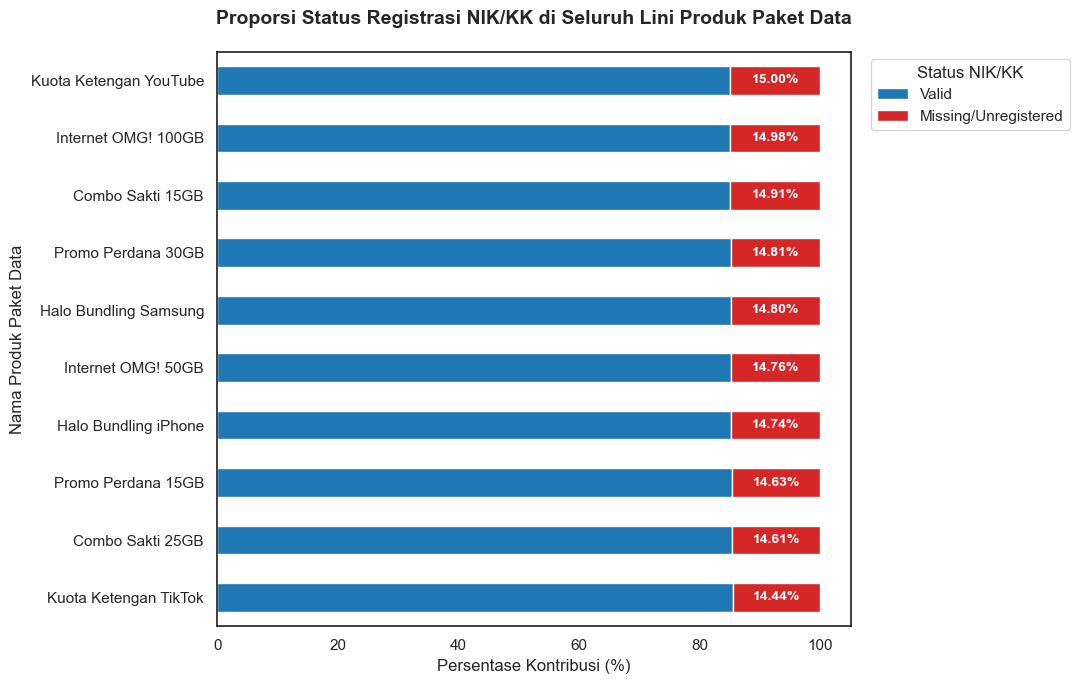

In [28]:
# Visualisasi
df_vis_nik = cross_nik_pct.loc[:, ['Valid', 'Missing/Unregistered']].sort_values(by='Missing/Unregistered')

sns.set_theme(style="white")
ax = df_vis_nik.plot(
    kind='barh', 
    stacked=True, 
    figsize=(11, 7), 
    color=['#1f77b4', '#d62728'] # Biru untuk valid, merah untuk missing
)

plt.title('Proporsi Status Registrasi NIK/KK di Seluruh Lini Produk Paket Data', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Persentase Kontribusi (%)', fontsize=12)
plt.ylabel('Nama Produk Paket Data', fontsize=12)
plt.legend(title='Status NIK/KK', bbox_to_anchor=(1.02, 1), loc='upper left')

#Menambahkan label
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_x(), p.get_y() 
    # Hanya beri label jika itu adalah batang 'Missing/Unregistered' (dimulai setelah batang Valid)
    if x > 0 and width > 0:
        ax.annotate(f"{width:.2f}%", 
                    (x + width/2, y + height/2), 
                    ha='center', va='center', 
                    color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Hasil ini membuktikan bahwa hilangnya data NIK/KK bukan disebabkan oleh aktivitas kecurangan eksternal (sindikat konter nakal). Jika ini ulah sindikat, angka Missing akan melonjak extreme hanya di paket Promo Perdana dan bernilai mendekati 0% di paket premium. Karena polanya seragam di semua paket, ini adalah bukti konkrit adanya kegagalan sistemik internal (Internal System Bug) pada gate/interface integrasi database antara Telkomsel dengan Dukcapil/Kominfo saat proses aktivasi kartu terjadi di seluruh lini produk.

### **4.3 Variasi Konsumsi Data Antar Jenis Paket**

Telkomsel menawarkan beberapa jenis paket data ke segmen pengguna yang berbeda, mulai dari paket Promo Perdana hingga paket premium seperti Halo Bundling. Asumsinya, pola konsumsi data per sesi pada paket premium akan lebih besar dibandingkan paket lain, sehingga berkontribusi signifikan terhadap ARPU. Untuk memvalidasi asumsi tersebut, akan dilakukan uji hipotesis statistik untuk mengetahui apakah terdapat perbedaan rata-rata konsumsi data per sesi antar jenis paket data.

Uji Hipotesis Statistik (One-Way ANOVA) untuk melihat apakah rata-rata konsumsi data per sesi (payload_mb) berbeda secara signifikan antar jenis paket data.

Hipotesis Uji:
- $H_0$: Tidak terdapat perbedaan rata-rata konsumsi data per sesi antar jenis paket data.
- $H_1$: Terdapat setidaknya 1 perbedaan rata-rata konsumsi data per sesi antar jenis paket.

In [29]:
# Uji ANOVA
from scipy.stats import f_oneway

groups = [grp['payload_mb'].values for name, grp in df_analisis.groupby('package_name')]
f_stat, p_value_anova = stats.f_oneway(*groups)

print(f"F-Statistic : {f_stat}")
print(f"P-Value     : {p_value_anova}")

if p_value < 0.05:
    print("Kesimpulan  : Tolak H0! Terdapat setidaknya 1 perbedaan rata-rata konsumsi data per sesi antar jenis paket")
    print("              Pola konsumsi data pelanggan berbeda antar jenis paket")
else:
    print("Kesimpulan  : Gagal Tolak H0. Tidak ada perbedaan signifikan")

F-Statistic : 0.5631000845240021
P-Value     : 0.8283479287516748
Kesimpulan  : Gagal Tolak H0. Tidak ada perbedaan signifikan


In [30]:
summary_paket = df_analisis.groupby('package_name').agg(
    total_sesi=('session_id', 'count'),
    total_payload_gb=('payload_mb', lambda x: x.sum() / 1024)
).reset_index()

print(summary_paket)

             package_name  total_sesi  total_payload_gb
0        Combo Sakti 15GB       28559      28539.387383
1        Combo Sakti 25GB       28770      28740.687529
2   Halo Bundling Samsung       28563      28552.831465
3    Halo Bundling iPhone       28353      28254.458926
4     Internet OMG! 100GB       28479      28509.960938
5      Internet OMG! 50GB       28500      28412.005303
6   Kuota Ketengan TikTok       28084      28201.952266
7  Kuota Ketengan YouTube       28464      28367.746660
8      Promo Perdana 15GB       28868      28948.012373
9      Promo Perdana 30GB       28513      28499.388525


In [31]:
rata_rata_paket = df_analisis.groupby('package_name')['payload_mb'].mean().reset_index()
rata_rata_paket.columns = ['package_name', 'avg_payload_mb']

print(rata_rata_paket.sort_values('avg_payload_mb', ascending=False))

             package_name  avg_payload_mb
6   Kuota Ketengan TikTok     1028.300781
8      Promo Perdana 15GB     1026.838183
4     Internet OMG! 100GB     1025.113241
2   Halo Bundling Samsung     1023.635452
9      Promo Perdana 30GB     1023.511165
0        Combo Sakti 15GB     1023.296778
1        Combo Sakti 25GB     1022.956692
5      Internet OMG! 50GB     1020.838366
7  Kuota Ketengan YouTube     1020.537260
3    Halo Bundling iPhone     1020.441080


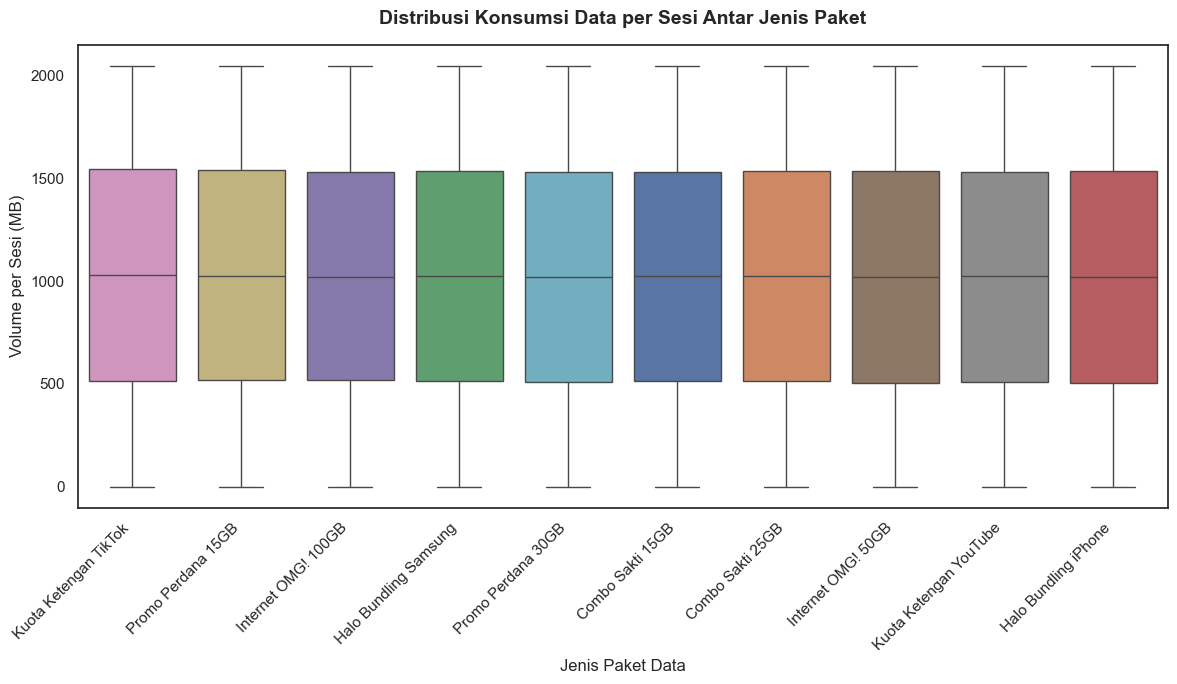

In [32]:
sns.set_theme(style="white")

semua_paket = sorted(df_analisis['package_name'].unique())
custom_palette = sns.color_palette("deep", n_colors=len(semua_paket))
color_map = dict(zip(semua_paket, custom_palette))

order_paket = df_analisis.groupby('package_name')['payload_mb'].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_analisis,
    x='package_name',
    y='payload_mb',
    order=order_paket,
    hue='package_name',
    palette=color_map, 
    legend=False
)

plt.title('Distribusi Konsumsi Data per Sesi Antar Jenis Paket', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jenis Paket Data', fontsize=12)
plt.ylabel('Volume per Sesi (MB)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


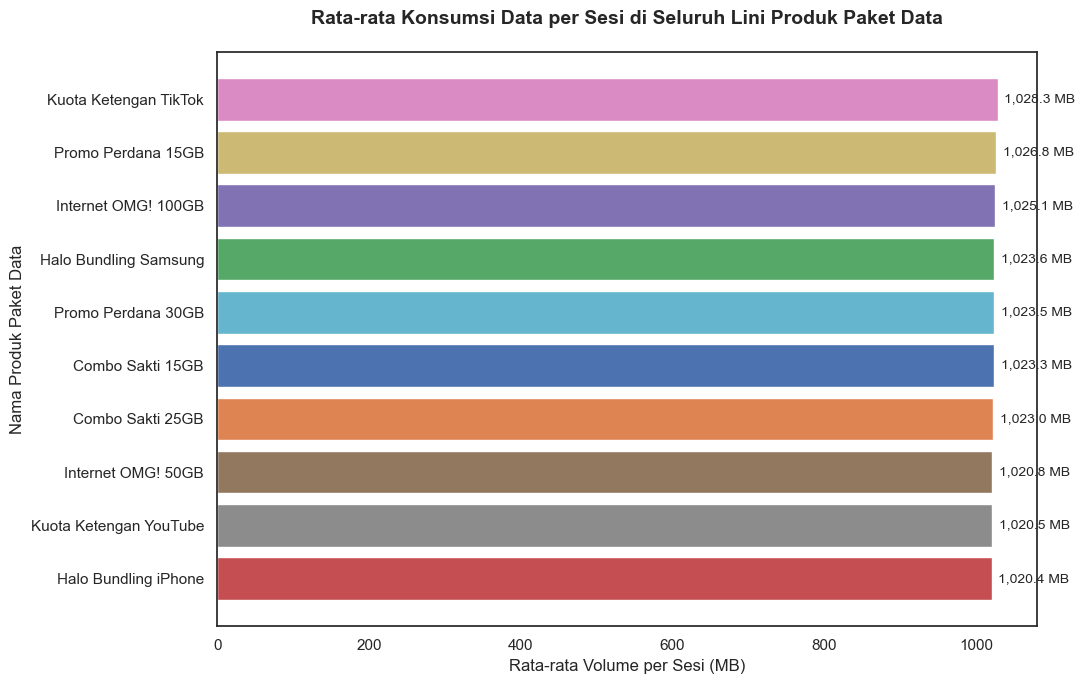

In [33]:
# visualisasi rata-rata konsumsi data per sesi, antar jenis paket
rata_rata_sort = rata_rata_paket.sort_values('avg_payload_mb', ascending=True)

bar_colors = [color_map[name] for name in rata_rata_sort['package_name']]
fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    rata_rata_sort['package_name'],
    rata_rata_sort['avg_payload_mb'],
    color=bar_colors
)

plt.title('Rata-rata Konsumsi Data per Sesi di Seluruh Lini Produk Paket Data', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Rata-rata Volume per Sesi (MB)', fontsize=12)
plt.ylabel('Nama Produk Paket Data', fontsize=12)

# Label angka di ujung tiap bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:,.1f} MB",
        (width, p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=10, xytext=(5, 0),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()


**Rekomendasi** :Karena rendahnya ARPU bukan disebabkan oleh rendahnya intensitas pemakaian data, melainkan oleh pemilihan paket harga termurah oleh pelanggan yang pola konsumsinya setara paket premium, maka perlu dipertimbangkan strategi tiering ulang pada Paket Promo Perdana, seperti pembatasan kuota harian atau pembatasan pemakaian kuota promo pada jam tertentu. Diharapkan, pelanggan dengan pemakaian kuota besar akan terdorong untuk upgrade ke paket reguler atau premium.

### **4.4 Analisis Seberapa Kotor dan Tidak Standar Penulisan Network Type**

In [34]:
network_unique = usage_raw['network_type'].nunique()
network_type = usage_raw['network_type'].value_counts()

print(f"Jumlah variasi penulisan unik dalam raw data: {network_unique} kategori")
print(network_type)

#penulisan standar industri hanyalah '3G', '4G', '5G'
standar = ['3G', '4G', '5G']
non_standar = usage_raw[~usage_raw['network_type'].isin(standar)]
pct_dirty = (len(non_standar) / len(usage_raw)) * 100

print(f"\nPersentase data network yang tidak standar/kotor: {pct_dirty:.2f}%")

Jumlah variasi penulisan unik dalam raw data: 10 kategori
network_type
4G        89981
LTE       44884
4G LTE    30339
5G        30075
4g        29833
WCDMA     15225
3G        15076
NR        14941
HSDPA     14905
5g        14741
Name: count, dtype: int64

Persentase data network yang tidak standar/kotor: 54.96%


> Lebih dari separuh log infrastruktur jaringan di database pusat Telkomsel ternyata terfragmentasi oleh kesalahan penulisan (formatting error). Ini adalah bukti konkrit bahwa data pipa (data pipeline) dari tower BTS ke Core Network tidak memiliki standarisasi skema yang ketat.



Evaluasi Dampak Bisnis & Tata Kelola Data (Data Governance)
1. **Misleading Reporting:** Tingkat kekotoran yang menembus **54.96%** ini sangat berbahaya bagi pengambilan keputusan manajemen. Jika tim *Network Operations* atau *Marketing* menarik laporan langsung dari raw data tanpa proses pembersihan, visualisasi performa trafik broadband akan terpecah menjadi 10 batang grafik terpisah. Hal ini memicu kesalahan interpretasi (misal: mengira jaringan 4G sedang turun, padahal trafikknya bocor ke penamaan `LTE` atau `4G LTE`).

2. **Urgensi Arsitektur Data Pipeline:** Temuan ini merekomendasikan tim *Data Engineering* untuk segera menerapkan fungsi transformasi otomatis (*Data Transformation Layer*) pada *Ingestion Pipeline* sebelum data masuk ke Data Lakehouse, sehingga format teks dari berbagai vendor perangkat keras (Huawei, Ericsson, Nokia) dikonversi secara real-time ke standar industri.


C:\Users\yoan.nita\AppData\Local\Temp\ipykernel_8248\3812058045.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\yoan.nita\AppData\Local\Temp\ipykernel_8248\3812058045.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


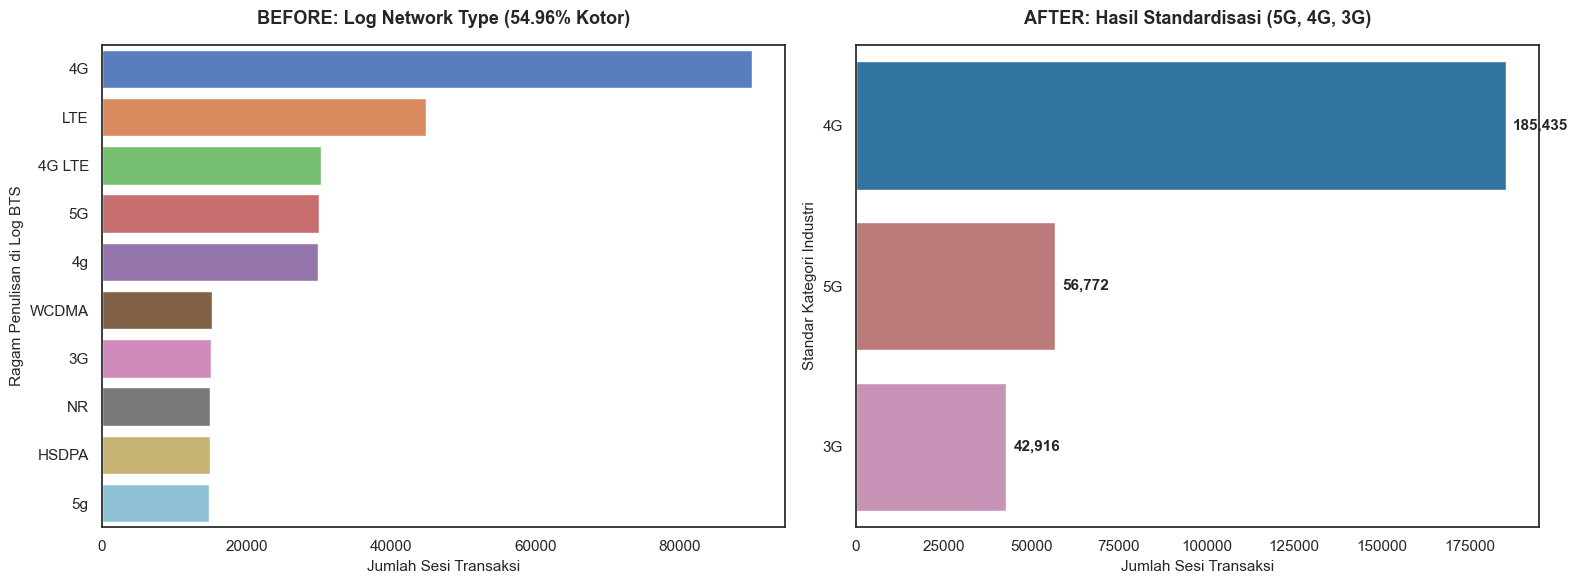

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 10 category
sns.barplot(
    x=usage_raw['network_type'].value_counts().values,
    y=usage_raw['network_type'].value_counts().index,
    ax=axes[0],
    palette='muted'
)
axes[0].set_title('BEFORE: Log Network Type (54.96% Kotor)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Jumlah Sesi Transaksi', fontsize=11)
axes[0].set_ylabel('Ragam Penulisan di Log BTS', fontsize=11)

# 3 category
sns.barplot(
    x=usage_clean['network_type'].value_counts().values,
    y=usage_clean['network_type'].value_counts().index,
    ax=axes[1],
    palette=['#1f77b4', '#c76e6e', '#d08abb'] 
)
axes[1].set_title('AFTER: Hasil Standardisasi (5G, 4G, 3G)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Jumlah Sesi Transaksi', fontsize=11)
axes[1].set_ylabel('Standar Kategori Industri', fontsize=11)

# Tambah angka di ujung barchart clean
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_width()):,}", 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', 
                     xytext=(5, 0), 
                     textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### **4.5 Analisis Dampak Kebocoran Log Kronologis (Logical Error: Sesi Sebelum Aktivasi Kartu)**

Analisis ini bertujuan untuk menjawab salah satu keanehan logika (*Logical Error*) terbesar dalam database, yaitu mengidentifikasi berapa banyak sesi penggunaan data (Data Usage Session) yang tercatat terjadi sebelum tanggal registrasi/aktivasi kartu SIM dilakukan.

Berdasarkan hasil audit kronologis dengan membandingkan variabel `session_time` terhadap `activation_date` pada data log raw, ditemukan temuan **Total Sesi Internet Ilegal:** **12.008 sesi** tercatat aktif melakukan transaksi data sebelum kartu SIM tersebut dinyatakan aktif secara legal oleh sistem.

In [36]:
display(anomaly_time.head())
anomaly_time.shape

,msisdn,session_time,payload_mb,session_id,package_code,activation_date,package_name,price
26,82254454198,2023-04-18,133.47,CDR000000027,PKG-008,2023-04-20,Combo Sakti 25GB,100000
34,82222192600,2023-10-04,758.03,CDR000000035,PKG-004,2023-10-11,Halo Bundling Samsung,200000
63,85272766900,2023-04-07,1090.95,CDR000000064,PKG-003,2023-04-09,Halo Bundling iPhone,250000
104,82120468327,2023-10-17,760.71,CDR000000105,PKG-010,2023-10-18,Kuota Ketengan TikTok,6000
124,81188580169,2023-02-15,409.70,CDR000000125,PKG-004,2023-02-18,Halo Bundling Samsung,200000


(12008, 8)

Untuk melihat apakah celah keamanan ini dieksploitasi secara sengaja pada produk tertentu, berikut adalah volume sesi ilegal yang diklasifikasikan pada kategori **"Pemakaian Asli"** (setelah memisahkan komponen *Bug System* yang memiliki pemakaian `999999.9` MB):

In [37]:
anomaly_time['error_type'] = np.where(
    anomaly_time['payload_mb'] >= 999999.9, 
    'Pemakaian Bug (999999.9)', 
    'Pemakaian Asli'
)

# Hitung distribusi frekuensi dan total payload volume
summary_anomaly = anomaly_time.groupby('error_type').agg(
    jumlah_sesi=('session_id', 'count'),
    total_payload_mb=('payload_mb', 'sum'),
    rata_rata_payload_mb=('payload_mb', 'mean')
).reset_index()


print("===Jumlah Sesi Ilegal Pada Setiap Paket===")
real_leakage = anomaly_time[anomaly_time['error_type'] == 'Pemakaian Asli']
print(real_leakage['package_name'].value_counts())

===Jumlah Sesi Ilegal Pada Setiap Paket===
package_name
Internet OMG! 50GB        1239
Internet OMG! 100GB       1227
Kuota Ketengan TikTok     1206
Halo Bundling Samsung     1205
Promo Perdana 15GB        1194
Combo Sakti 25GB          1190
Promo Perdana 30GB        1185
Halo Bundling iPhone      1184
Kuota Ketengan YouTube    1182
Combo Sakti 15GB          1137
Name: count, dtype: int64


C:\Users\yoan.nita\AppData\Local\Temp\ipykernel_8248\4025681077.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomaly_time['error_type'] = np.where(


Distribusi data di atas menunjukkan pola yang sangat homogen (konstan di kisaran 1.100 - 1.200 sesi untuk seluruh produk tanpa terkecuali). Fakta ini mematahkan asumsi adanya pola kecurangan terstruktur oleh pihak luar (*targeted hacking*). 

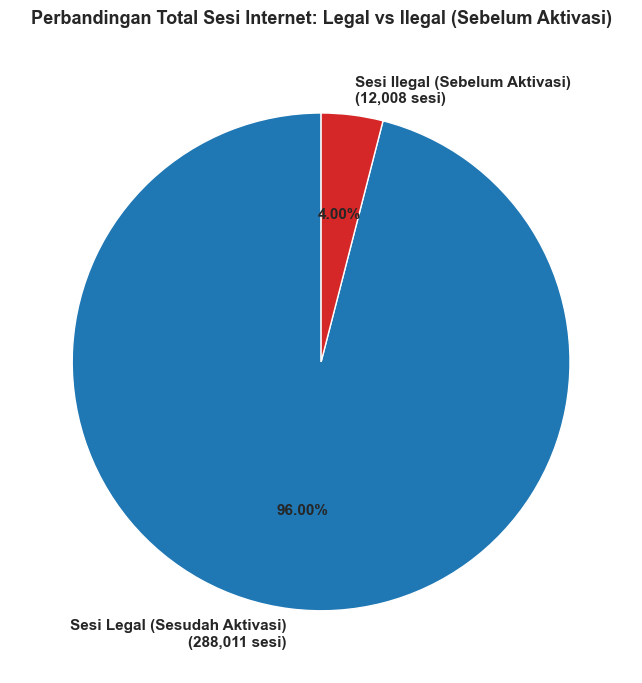

Total Seluruh Sesi di Database : 300,019 sesi
Proporsi Sesi Ilegal           : 4.00%


In [38]:
# Hitung jumlah sesi legal vs ilegal
total_sesi_all = len(df_merge_time)
sesi_ilegal = len(anomaly_time)
sesi_legal = total_sesi_all - sesi_ilegal

labels = [f'Sesi Legal (Sesudah Aktivasi)\n({sesi_legal:,} sesi)', 
          f'Sesi Ilegal (Sebelum Aktivasi)\n({sesi_ilegal:,} sesi)']
sizes = [sesi_legal, sesi_ilegal]
colors = ['#1f77b4', '#d62728'] # Biru untuk Aman/Legal, Merah untuk Alert/Ilegal

plt.figure(figsize=(7, 7))
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%', 
    startangle=90, 
    colors=colors,
    wedgeprops=dict(edgecolor='w'), 
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title('Perbandingan Total Sesi Internet: Legal vs Ilegal (Sebelum Aktivasi)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"Total Seluruh Sesi di Database : {total_sesi_all:,} sesi")
print(f"Proporsi Sesi Ilegal           : {(sesi_ilegal / total_sesi_all) * 100:.2f}%")


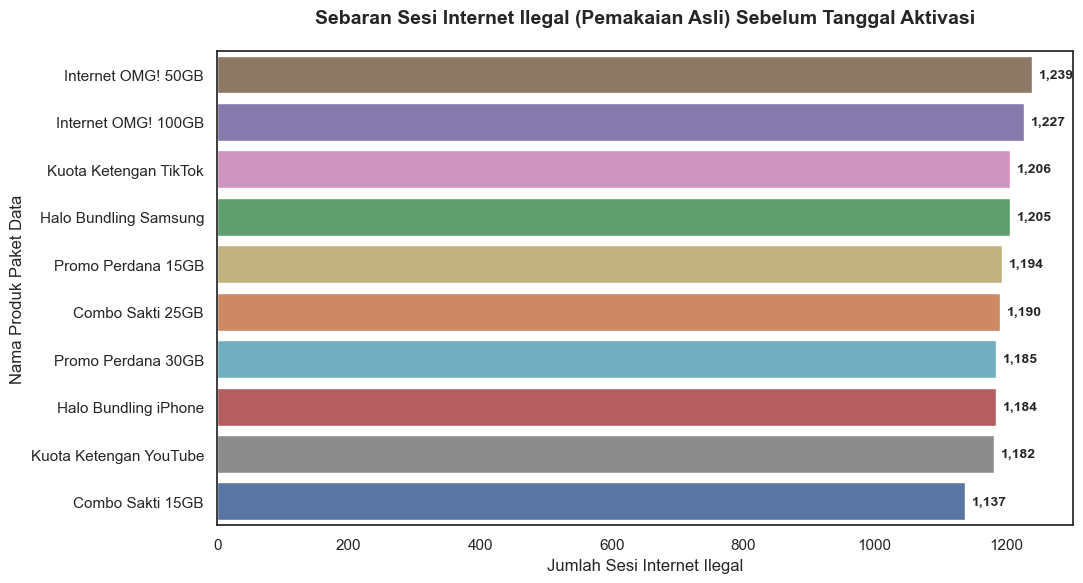

In [39]:
df_vis_leakage = real_leakage['package_name'].value_counts().reset_index()
df_vis_leakage.columns = ['package_name', 'jumlah_sesi_ilegal']

bar_colors_leakage = [color_map[name] for name in df_vis_leakage['package_name']]

plt.figure(figsize=(11, 6))

# Horizontal Bar Chart
sns.barplot(
    data=df_vis_leakage,
    x='jumlah_sesi_ilegal',
    y='package_name',
    palette=bar_colors_leakage,  
    hue='package_name',         
    legend=False
)

plt.title('Sebaran Sesi Internet Ilegal (Pemakaian Asli) Sebelum Tanggal Aktivasi', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Jumlah Sesi Internet Ilegal', fontsize=12)
plt.ylabel('Nama Produk Paket Data', fontsize=12)

# Menambahkan label angka di ujung setiap batang
for p in plt.gca().patches:
    plt.gca().annotate(
        f"{int(p.get_width()):,}", 
        (p.get_width(), p.get_y() + p.get_height() / 2.), 
        ha='left', va='center', 
        xytext=(5, 0), 
        textcoords='offset points', 
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


- **Akar Masalah (*Root Cause*):** Pola seragam ini mengonfirmasi adanya **Provisioning Delay Bug** pada level infrastruktur jaringan utama. Terjadi kegagalan atau keterlambatan data antara *Gateway GPRS Support Node* (GGSN) dengan database billing pusat saat memetakan kartu baru yang beredar di pasar, sehingga trafik data langsung mengalir secara anonim sebelum tanggal aktivasi ter-update.

- **Rekomendasi Pengetatan Arsitektur Jaringan:** Manajemen disarankan untuk menerapkan kebijakan *strict authentication gating* pada HLR (*Home Location Register*). Seluruh kartu perdana yang belum melewati trigger sukses API registrasi prabayar wajib dikunci total profil datanya pada level core network agar kebocoran log data kronologis ini tidak terus berulang.

### **4.6 Analisis Outliers / Billing Bug**

Analisis ini bertujuan untuk mendeteksi lonjakan pemakaian data (payload_mb) yang tidak wajar dalam satu sesi transaksi tunggal. Kita ingin membuktikan apakah ada sesi internet yang menghabiskan kuota raksasa secara instan (misal puluhan ribu MB dalam hitungan detik), yang menjadi indikator kuat adanya bug billing system atau eksploitasi jalur koneksi (tethering abuse).

In [40]:
# Batas extreme menggunakan Persentil 99.9
threshold_ekstrem = df_analisis['payload_mb'].quantile(0.999)

# Isolasi data yang menembus batas extreme
df_outliers = df_analisis[df_analisis['payload_mb'] > threshold_ekstrem].copy()

print(f"Threshold (Persentil 99.9)              : {threshold_ekstrem:,.2f} MB")
print(f"Jumlah Sesi Terdeteksi Extreme          : {len(df_outliers)} sesi")
print(f"Total Kuota yang Disedot Sesi Extreme   : {df_outliers['payload_mb'].sum() / 1024:,.2f} GB\n")

# Distribusi paket data yang memiliki outlier
print(df_outliers['package_name'].value_counts())

# Sample
print("\n")
print(df_outliers[['msisdn', 'package_name', 'network_type', 'payload_mb']].head())

Threshold (Persentil 99.9)              : 2,045.92 MB
Jumlah Sesi Terdeteksi Extreme          : 283 sesi
Total Kuota yang Disedot Sesi Extreme   : 565.70 GB

package_name
Internet OMG! 50GB        36
Internet OMG! 100GB       31
Combo Sakti 25GB          31
Promo Perdana 30GB        30
Halo Bundling Samsung     29
Kuota Ketengan YouTube    28
Promo Perdana 15GB        27
Halo Bundling iPhone      25
Combo Sakti 15GB          24
Kuota Ketengan TikTok     22
Name: count, dtype: int64


           msisdn            package_name network_type  payload_mb
486   81258421172  Kuota Ketengan YouTube           4G     2047.35
522   81128897744      Promo Perdana 15GB           5G     2046.05
1366  82253586834   Kuota Ketengan TikTok           4G     2047.41
3054  85278965861   Kuota Ketengan TikTok           4G     2047.46
6011  82293306698        Combo Sakti 15GB           4G     2046.82


Penggunaan data sebesar ~2.046 MB (atau sekitar 2 GB) dalam satu sesi internet di era modern (2026) saat ini, terutama dengan adanya jaringan 4G dan 5G adalah hal yang sangat wajar dan normal. Angka ini merepresentasikan aktivitas umum pengguna seperti melakukan streaming video kualitas 4K di YouTube/TikTok, mengunduh pembaruan game besar, atau melakukan tethering laptop selama beberapa jam.

> angka ini keluar sebagai outlier karena nilai eror sistem sesungguhnya (999999.9 MB atau ~1 TB per sesi) sudah kita bersihkan dengan bersih di Section 3. Ketika pencilan yang sangat raksasa itu hilang, batas persentil 99.9 otomatis turun drastis ke angka pemakaian tertinggi manusia normal (yaitu 2 GB per sesi).

Untuk membuktikan secara visual bahwa kelompok pemakaian tertinggi ini masih berada dalam pemakaian normal (~2 GB) dan tidak melonjak lebih dari itu, kita bisa lihat dari grafik scatter Plot

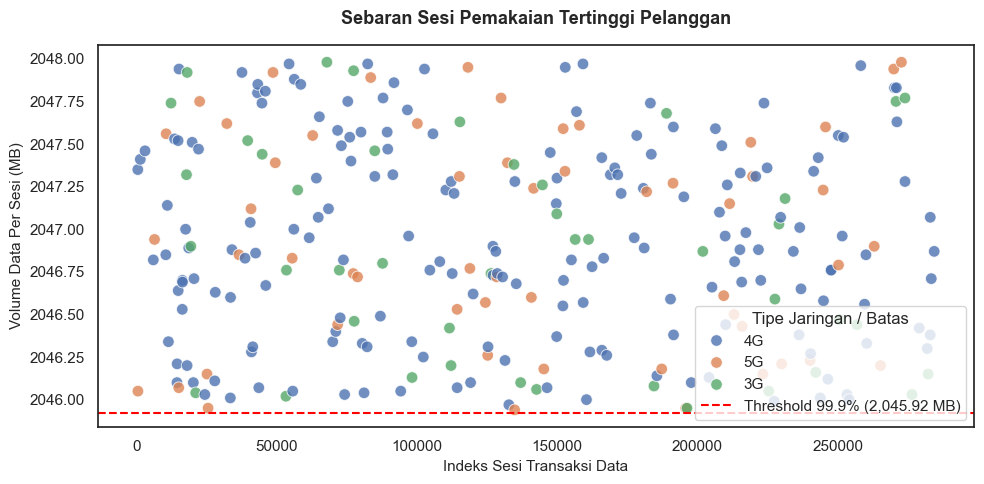

In [41]:
plt.figure(figsize=(10, 5))

# Membuat Scatter Plot untuk 283 data outlier normal
sns.scatterplot(
    data=df_outliers,
    x=df_outliers.index, # Menggunakan indeks baris sebagai penyebaran horizontal
    y='payload_mb',
    hue='network_type',
    alpha=0.8,
    s=70
)

# Menambahkan garis batas persentil 99.9
plt.axhline(y=threshold_ekstrem, color='red', linestyle='--', linewidth=1.5, label=f'Threshold 99.9% ({threshold_ekstrem:,.2f} MB)')

plt.title('Sebaran Sesi Pemakaian Tertinggi Pelanggan', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Indeks Sesi Transaksi Data', fontsize=11)
plt.ylabel('Volume Data Per Sesi (MB)', fontsize=11)
plt.legend(title='Tipe Jaringan / Batas', loc='lower right')

plt.tight_layout()
plt.show()

#### 4.6.1 Informasi Tambahan

Untuk membuktikan bahwa tidak ada pemakaian data ('payload_mb') di rentan 2,048 MB sampai dengan 999,999 MB



In [42]:
batas_bawah = 2048
batas_atas = 999999

data_di_rentang_kosong = df_merge_time[(df_merge_time['payload_mb'] > batas_bawah) & (df_merge_time['payload_mb'] < batas_atas)]

print(f"Jumlah sesi internet di antara {batas_bawah:,} MB s.d {batas_atas:,} MB: {len(data_di_rentang_kosong)} sesi.")

Jumlah sesi internet di antara 2,048 MB s.d 999,999 MB: 0 sesi.


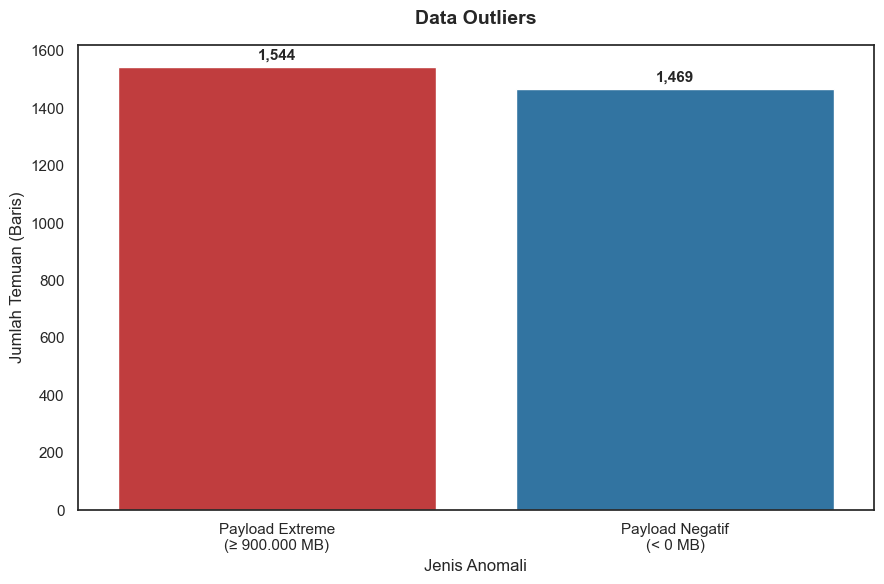

In [43]:
# Data Quality Scorecard: rekap jumlah temuan per jenis anomali sistem
scorecard = pd.DataFrame({
    'jenis_anomali': [
        'Payload Extreme\n(≥ 900.000 MB)',
        'Payload Negatif\n(< 0 MB)'
    ],
    'jumlah_temuan': [
        len(outlier_extreme),
        len(outlier_extreme_min)
    ]
})

plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=scorecard,
    x='jenis_anomali',
    y='jumlah_temuan',
    hue='jenis_anomali',
    palette=['#d62728', '#1f77b4'],
    legend=False
)

plt.title('Data Outliers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jenis Anomali', fontsize=12)
plt.ylabel('Jumlah Temuan (Baris)', fontsize=12)

# label angka di atas tiap bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

Fakta bahwa sebaran 283 sesi ini sangat merata di semua paket (dari paket murah Ketengan seharga seribuan hingga paket Premium Bundling) dan mentok di angka batas atas ~2.047 MB membuktikan:

- Tidak Ada Tethering Abuse Ekstrem: Pengguna prabayar Telkomsel tidak melakukan eksploitasi kuota hingga puluhan ribu MB secara ilegal lewat celah sistem.

- Billing System Pasca-Pembersihan Terbukti Sehat: Di luar kode eror 999999.9 yang sudah kita eliminasi, pencatatan kuota riil oleh database pusat Telkomsel memiliki batas wajar pemakaian.

## **Section 5. Conclusion and Recommendation**

**5.1 Conclusion**

• Analisis penyalahgunaan Program Device Bundling menunjukkan adanya penggunaan kartu SIM pada perangkat yang berbeda (IMEI Mismatch). Meskipun pola pemakaian data normal (~1 GB/sesi), kondisi ini menyebabkan kebocoran anggaran subsidi karena target akusisi segmen high-value smartphone users gagal.

•	Dugaan penggunaan NIK/KK tidak valid pada Paket Promo Perdana dan dugaan pendaftaran illegal masal tidak didukung oleh data. Proporsi status Missing/Unregistered terdistribusi merata di seluruh produk (±14,4–15,0%), sehingga temuan lebih mengarah pada kegagalan sistemik internal pada gate integrasi database Telkomsel dengan Dukcapil/Kominfo.

•	Investigasi dampak Bakar Perdana melalui pola konsumsi data menunjukkan pelanggan Paket Promo Perdana memiliki tingkat penggunaan data yang setara dengan paket reguler dan premium. Rendahnya ARPU bukan disebabkan oleh rendahnya intensitas konsumsi penggunaan data pada Paket Promo Perdana.

•	Audit integritas data menemukan tiga permasalahan yaitu pertama, 54.96% log jaringan BTS terdapat inkonsistensi network type berpotensi memicu bias pada interpretasi laporan. Kedua, tercatat sebanyak 12.008 sesi illegal (activation period < session time) mengindikasikan kegagalan sinkronisasi GGSN dan database billing. Ketiga, ditemukan anomali pada nilai billing (999.999,9 MB dan -150,5 MB)  mengindikasikan bug billing. 

**5.2 Recommendation**